# 1. Setup

## 1.1 Mount Drive

Keeps the checkpoint and sample results saved between sessions, since local disk gets wiped on
every restart.

In [ ]:
# Mounts at /content/drive — used later for the checkpoint and sample-results output paths
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 1.2 Check the GPU

Should print True and a GPU name, usually a Tesla T4 on the free tier.

In [ ]:
# Should print True + a GPU name (e.g. Tesla T4). If False, go to
# Runtime > Change runtime type and select a GPU before continuing.
import torch
print("CUDA available:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "none")

CUDA available: True
GPU: Tesla T4


## 1.3 Get the Dataset

Downloads the official release from its public S3 bucket, no AWS account needed, and extracts it
locally. Licence and citation are in Methodology.md.

In [ ]:
# The AWS CLI is needed to pull the dataset directly from its S3 bucket
!pip install -q awscli

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.2/20.2 MB 94.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 570.5/570.5 kB 43.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sphinx 8.2.3 requires docutils<0.22,>=0.20, but you have docutils 0.19 which is incompatible.


In [ ]:
# Sanity check that the CLI installed correctly
!aws --version

aws-cli/1.46.1 Python/3.13.15 Linux/6.6.122+ botocore/1.43.62


In [ ]:
# Anonymous S3 download (no AWS credentials needed) — ~19.6 GB, the supervised
# release of Agriculture-Vision (Chiu et al., CVPR 2020). See Methodology.md
!aws s3 cp s3://intelinair-data-releases/agriculture-vision/cvpr_challenge_2021/supervised/Agriculture-Vision-2021.tar.gz "/content/Agriculture-Vision-2021.tar.gz" --no-sign-request

download: s3://intelinair-data-releases/agriculture-vision/cvpr_challenge_2021/supervised/Agriculture-Vision-2021.tar.gz to ./Agriculture-Vision-2021.tar.gz


In [ ]:
# Extract to local Colab disk (fast, ephemeral) rather than Drive (slow for many small files)
!tar -xzf "/content/Agriculture-Vision-2021.tar.gz" -C /content

In [ ]:
# Confirm the extraction succeeded before proceeding
import os
print("dataset exists:", os.path.exists("/content/Agriculture-Vision-2021"))

dataset exists: True


## 1.4 Install the Segmentation Library

segmentation-models-pytorch gives pretrained encoders and decoders like DeepLabV3+ behind one
simple API.

In [ ]:
# segmentation-models-pytorch: pretrained encoders + decoder architectures (DeepLabV3+, U-Net, ...)
!pip install -q segmentation-models-pytorch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 5.5 MB/s eta 0:00:00


## 1.5 Imports and a Fixed Seed

Fixes the random seed so sampling and initialization are reproducible.

In [ ]:
# Core library imports (seeding moved to the config cell below)
import os, random
import numpy as np
from PIL import Image
import torch
import segmentation_models_pytorch as smp

print("smp version:", smp.__version__)
print("torch version:", torch.__version__)

smp version: 0.5.0
torch version: 2.11.0+cu128


## 1.6 One Config for Everything

Every hyperparameter lives in this one dict. Change a value here and rerun from this cell down.

In [ ]:
CONFIG = {
    "seed": 42,

    # Data sampling (Methodology.md)
    "positive_coverage_threshold": 0.20,  # min drydown coverage to count as "positive"
    "train_pos": 1500, "train_neg": 1500,
    "val_pos": 200, "val_neg": 200,
    "test_pos": 100, "test_neg": 100,

    # DataLoader
    "batch_size": 8,  # doubled again from 32 -- watch VRAM, drop back if it OOMs
    "num_workers": 2,  # matches Colab free-tier CPU count

    # Model (Methodology.md)
    "encoder_name": "resnet50",  # up from resnet34 -- more capacity now that augmentation
    "encoder_weights": "imagenet", # reduces the memorization risk that would make this risky
    "in_channels": 4,
    "classes": 1,

    # Training (Methodology.md)
    "epochs": 100,
    "lr": 1e-4,  # kept at the batch-32 value, NOT doubled again for batch-48 -- too many
    "weight_decay": 1e-4, # simultaneous changes already (resnet50, bigger train/val) to also stack
    "warmup_epochs": 1,# a second LR jump and still be able to tell what caused what
    "early_stopping_patience": 15,  # stop if val_iou has not improved in this many epochs

    # Train-time augmentation (Methodology.md -- planned in the baseline pass,
    # implemented in the Enhanced pass): random flips/90-degree rotations + RGB
    # brightness/contrast jitter. Applied only to the training set, never to val/test.
    "use_augmentation": True,

    # Probability-threshold sweep for the model (Methodology.md)
    "prob_thresh_min": 0.10, "prob_thresh_max": 0.95, "prob_thresh_step": 0.05,

    # NDVI-threshold sweep for the baseline (Methodology.md)
    "ndvi_thresh_min": -0.50, "ndvi_thresh_max": 0.70, "ndvi_thresh_step": 0.05,

    # Output paths -- separate "v2" subfolder so this run does not overwrite the
    # Enhanced v1 checkpoint/results while that comparison is still needed
    "ckpt_path": "/content/drive/MyDrive/Rizoma/DeepLabV3_Drydown/Enhanced/best_deeplabv3plus.pth",
    "sample_out_dir": "/content/drive/MyDrive/Rizoma/DeepLabV3_Drydown/Enhanced/sample_results",
}

random.seed(CONFIG["seed"])
np.random.seed(CONFIG["seed"])
torch.manual_seed(CONFIG["seed"])

print("Config loaded:")
for k, v in CONFIG.items():
    print(f"  {k}: {v}")

Config loaded:
  seed: 42
  positive_coverage_threshold: 0.2
  train_pos: 1500
  train_neg: 1500
  val_pos: 200
  val_neg: 200
  test_pos: 100
  test_neg: 100
  batch_size: 8
  num_workers: 2
  encoder_name: resnet50
  encoder_weights: imagenet
  in_channels: 4
  classes: 1
  epochs: 100
  lr: 0.0001
  weight_decay: 0.0001
  warmup_epochs: 1
  early_stopping_patience: 15
  use_augmentation: True
  prob_thresh_min: 0.1
  prob_thresh_max: 0.95
  prob_thresh_step: 0.05
  ndvi_thresh_min: -0.5
  ndvi_thresh_max: 0.7
  ndvi_thresh_step: 0.05
  ckpt_path: /content/drive/MyDrive/Rizoma/DeepLabV3_Drydown/Enhanced/best_deeplabv3plus.pth
  sample_out_dir: /content/drive/MyDrive/Rizoma/DeepLabV3_Drydown/Enhanced/sample_results


# 2. Data

## 2.1 Build the Splits

Builds a field disjoint, class balanced subset rather than training on the full dataset. Full
reasoning is in Methodology.md.

Fields never appear in more than one split. A first, random 50/50 split of fields put 2,768
positive images in one half and only 1,725 in the other, so fields are instead assigned to
balance the actual share of positives, not just the field count. Each split samples an equal
number of positive and negative images. This pass uses 3,000 train images instead of 800, more
than twice the baseline, to fight the overfitting the baseline showed. Sizes: 3,000 train, 400
validation, 200 test.

In [ ]:
# coverage_map(): for every image in a split, computes what fraction of its
# pixels are labeled `drydown` (0.0-1.0). Used below to filter images by
# how much (if any) drydown signal they contain.
ROOT = "/content/Agriculture-Vision-2021"

def coverage_map(split):
    folder = f"{ROOT}/{split}/labels/drydown"
    result = {}
    for f in os.listdir(folder):
        m = np.array(Image.open(os.path.join(folder, f)))
        result[f] = (m > 0).mean()
    return result

train_cov = coverage_map("train")
val_cov = coverage_map("val")

# Stratified field split (fixes a real skew found via the EDA notebook): a plain random
# 50/50 split of val's fields put 2,768 positive images in one half and only
# 1,725 in the other, despite equal field counts, since positives aren't evenly
# spread across fields. Instead, count each field's positive-coverage images,
# sort fields largest-first, and greedily assign each field to whichever half
# currently has fewer accumulated positives — balancing the actual positive
# SHARE, not just the field count. Fields with zero positives are alternated
# afterward to keep field counts roughly even too.
threshold = CONFIG["positive_coverage_threshold"]
field_pos_counts = {}
for f, c in val_cov.items():
    if c >= threshold:
        field = f.split("_")[0]
        field_pos_counts[field] = field_pos_counts.get(field, 0) + 1

val_fields = sorted(set(f.split("_")[0] for f in val_cov))
fields_with_pos = sorted(
    [f for f in val_fields if f in field_pos_counts],
    key=lambda f: field_pos_counts[f],
    reverse=True,
)
fields_without_pos = [f for f in val_fields if f not in field_pos_counts]
random.shuffle(fields_without_pos)

val_fields_set, test_fields_set = set(), set()
val_pos_total, test_pos_total = 0, 0

for f in fields_with_pos:
    if val_pos_total <= test_pos_total:
        val_fields_set.add(f)
        val_pos_total += field_pos_counts[f]
    else:
        test_fields_set.add(f)
        test_pos_total += field_pos_counts[f]

for i, f in enumerate(fields_without_pos):
    (val_fields_set if i % 2 == 0 else test_fields_set).add(f)

# Negatives were never the constraint (thousands available either side), but
# verifying both counts — not just positives — confirms the split is sound
# rather than assuming it based on positives alone.
val_neg_total = sum(1 for f, c in val_cov.items() if c == 0 and f.split("_")[0] in val_fields_set)
test_neg_total = sum(1 for f, c in val_cov.items() if c == 0 and f.split("_")[0] in test_fields_set)

print(f"validation half: {len(val_fields_set)} fields -> {val_pos_total} positive, {val_neg_total} negative candidates")
print(f"test half:       {len(test_fields_set)} fields -> {test_pos_total} positive, {test_neg_total} negative candidates")

# pick(): randomly samples n_pos images with >=CONFIG["positive_coverage_threshold"]
# drydown coverage and n_neg images with 0% coverage, optionally restricted to a
# given set of field IDs (used to enforce the val/test field-disjoint split above).
def pick(cov_dict, n_pos, n_neg, allowed_fields=None):
    threshold = CONFIG["positive_coverage_threshold"]
    pos = [f for f, c in cov_dict.items() if c >= threshold and (allowed_fields is None or f.split("_")[0] in allowed_fields)]
    neg = [f for f, c in cov_dict.items() if c == 0 and (allowed_fields is None or f.split("_")[0] in allowed_fields)]
    if len(pos) < n_pos:
        raise ValueError(f"Requested {n_pos} positive images but only {len(pos)} are available in this pool.")
    if len(neg) < n_neg:
        raise ValueError(f"Requested {n_neg} negative images but only {len(neg)} are available in this pool.")
    return random.sample(pos, n_pos), random.sample(neg, n_neg)

# Split sizes now come from CONFIG — see Methodology.md for the rationale
# behind the default 800/200/200 sizing and the positive/negative balance.
train_pos, train_neg = pick(train_cov, CONFIG["train_pos"], CONFIG["train_neg"])
val_pos, val_neg = pick(val_cov, CONFIG["val_pos"], CONFIG["val_neg"], val_fields_set)
test_pos, test_neg = pick(val_cov, CONFIG["test_pos"], CONFIG["test_neg"], test_fields_set)

print("train:", len(train_pos), len(train_neg))
print("val:", len(val_pos), len(val_neg))
print("test:", len(test_pos), len(test_neg))

validation half: 328 fields -> 2247 positive, 5919 negative candidates
test half:       328 fields -> 2246 positive, 6615 negative candidates
train: 1500 1500
val: 200 200
test: 100 100


## 2.2 Load RGB and NIR, with Augmentation

Stacks RGB and NIR into one four channel input. The target is the drydown mask, binarized to 0
or 1. Boundaries and masks together define which pixels are valid, and those are excluded from
both the loss and the evaluation.

New in this pass: random flips, random 90 degree rotation, and brightness and contrast jitter on
the training set only. Flips and 90 degree turns are safe for these square tiles, no black
border artifacts the way an arbitrary angle rotation would cause. Validation and test are never
augmented.

In [ ]:
import torch
from torch.utils.data import Dataset
import numpy as np
from PIL import Image
import os

class DrydownDataset(Dataset):
    """Loads one Agriculture-Vision sample as (image, target, loss_mask):
    - image: RGB+NIR stacked into a 4-channel tensor, normalized to [0, 1]
    - target: the drydown mask, binarized to 0/1
    - loss_mask: boundaries and valid-pixel mask, to exclude invalid/off-field
      pixels from both the loss function and evaluation metrics

    Augmentation (train split only, Methodology.md section 7): random horizontal/
    vertical flip and random 90-degree rotation (geometry-safe for these
    already-cropped square tiles), plus RGB-only brightness/contrast jitter.
    Never applied to val/test -- those must stay a faithful, unmodified sample.
    """
    def __init__(self, filenames, split, root="/content/Agriculture-Vision-2021", augment=False):
        self.filenames = filenames
        self.split = split
        self.root = root
        self.augment = augment

    def __len__(self):
        return len(self.filenames)

    def __getitem__(self, idx):
        fname = self.filenames[idx]
        base = fname.replace(".png", ".jpg")

        rgb = np.array(Image.open(f"{self.root}/{self.split}/images/rgb/{base}").convert("RGB"))
        nir = np.array(Image.open(f"{self.root}/{self.split}/images/nir/{base}").convert("L"))
        mask = np.array(Image.open(f"{self.root}/{self.split}/labels/drydown/{fname}"))
        boundary = np.array(Image.open(f"{self.root}/{self.split}/boundaries/{fname}"))
        valid = np.array(Image.open(f"{self.root}/{self.split}/masks/{fname}"))

        if self.augment:
            rgb, nir, mask, boundary, valid = self._augment(rgb, nir, mask, boundary, valid)

        # Stack RGB + NIR into one 4-channel input tensor (Methodology.md section 3)
        img = np.concatenate([rgb, nir[:, :, None]], axis=2).astype(np.float32) / 255.0
        img = torch.from_numpy(img).permute(2, 0, 1)  # (4, H, W)

        target = torch.from_numpy((mask > 0).astype(np.float32)).unsqueeze(0)  # (1, H, W)
        loss_mask = torch.from_numpy(((boundary > 0) & (valid > 0)).astype(np.float32)).unsqueeze(0)

        return img, target, loss_mask

    def _augment(self, rgb, nir, mask, boundary, valid):
        # Random horizontal flip
        if random.random() < 0.5:
            rgb, nir, mask, boundary, valid = [np.fliplr(a) for a in (rgb, nir, mask, boundary, valid)]
        # Random vertical flip
        if random.random() < 0.5:
            rgb, nir, mask, boundary, valid = [np.flipud(a) for a in (rgb, nir, mask, boundary, valid)]
        # Random 0/90/180/270 rotation -- geometry-safe for square crops, avoids
        # the black-border artifacts an arbitrary-angle rotation would introduce
        k = random.randint(0, 3)
        if k:
            rgb, nir, mask, boundary, valid = [np.rot90(a, k) for a in (rgb, nir, mask, boundary, valid)]

        # RGB-only brightness/contrast jitter -- never applied to NIR or any mask,
        # since those must stay an accurate physical/annotation signal
        rgb = rgb.astype(np.float32)
        contrast = random.uniform(0.85, 1.15)
        brightness = random.uniform(-15, 15)
        rgb = np.clip(rgb * contrast + brightness, 0, 255).astype(np.uint8)

        # np.rot90/fliplr/flipud return non-contiguous views; torch.from_numpy
        # requires contiguous arrays
        return (np.ascontiguousarray(rgb), np.ascontiguousarray(nir), np.ascontiguousarray(mask),
                np.ascontiguousarray(boundary), np.ascontiguousarray(valid))

print("Dataset class defined (train-split augmentation: flip/rotate/brightness-contrast)")

Dataset class defined (train-split augmentation: flip/rotate/brightness-contrast)


## 2.3 DataLoaders and a Sanity Check

Wraps each dataset in a DataLoader and pulls one batch to confirm the shapes look right.
Augmentation only applies to the training loader.

In [ ]:
# Training is shuffled; validation/test are not -- later error-analysis code
# relies on test_loader iteration order matching test_files exactly.
# Augmentation applies to train_ds only (Methodology.md section 7) -- val/test must
# stay a faithful, unmodified sample for honest evaluation.
from torch.utils.data import DataLoader

train_files = train_pos + train_neg
val_files = val_pos + val_neg
test_files = test_pos + test_neg

train_ds = DrydownDataset(train_files, split="train", augment=CONFIG["use_augmentation"])
val_ds = DrydownDataset(val_files, split="val", augment=False)
test_ds = DrydownDataset(test_files, split="val", augment=False)  # test images also live under the "val" folder on disk

train_loader = DataLoader(train_ds, batch_size=CONFIG["batch_size"], shuffle=True, num_workers=CONFIG["num_workers"])
val_loader = DataLoader(val_ds, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=CONFIG["num_workers"])
test_loader = DataLoader(test_ds, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=CONFIG["num_workers"])

# Sanity check: pull one batch and confirm shapes
imgs, targets, loss_masks = next(iter(train_loader))
print("images:", imgs.shape)       # expect (batch_size, 4, 512, 512)
print("targets:", targets.shape)   # expect (batch_size, 1, 512, 512)
print("loss_masks:", loss_masks.shape)

images: torch.Size([8, 4, 512, 512])
targets: torch.Size([8, 1, 512, 512])
loss_masks: torch.Size([8, 1, 512, 512])


# 3. Model

## 3.1 DeepLabV3+, Four Channels

DeepLabV3+ with a pretrained ResNet 34 encoder, the same architecture the original paper used as
its own strongest baseline. The library adapts the pretrained three channel input to four
channels automatically.

In [ ]:
# in_channels=4 (RGB+NIR): smp automatically adapts the pretrained 3-channel
# first conv layer to 4 channels (averaging + tiling pretrained weights) —
# no manual weight surgery needed.
model = smp.DeepLabV3Plus(
    encoder_name=CONFIG["encoder_name"],
    encoder_weights=CONFIG["encoder_weights"],
    in_channels=CONFIG["in_channels"],
    classes=CONFIG["classes"],
    activation=None,  # raw logits; we'll apply sigmoid in the loss/metric functions
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

# Sanity check: run one batch through the untrained model
imgs, targets, loss_masks = next(iter(train_loader))
imgs = imgs.to(device)
with torch.no_grad():
    out = model(imgs)
print("output shape:", out.shape)  # expect (batch_size, 1, 512, 512)

/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_auth.py:138: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
  warnings.warn(f"\nError while fetching `HF_TOKEN` secret value from your vault: '{str(e)}'.")


config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  102MB            

model.safetensors: downloading bytes:           |  0.00B            

output shape: torch.Size([8, 1, 512, 512])


## 3.2 Loss: BCE Plus Dice

Combines binary cross entropy with Dice loss to handle the class imbalance, since drydown pixels
are a minority even in positive images. Both terms are masked so invalid pixels never affect the
gradient.

In [ ]:
# BCE handles per-pixel classification; Dice directly rewards mask overlap,
# which helps counter the severe positive/negative pixel imbalance in this task.
import torch.nn as nn
import torch.nn.functional as F

def masked_bce_dice_loss(logits, targets, loss_mask, smooth=1.0):
    probs = torch.sigmoid(logits)

    # BCE per-pixel, masked
    bce = F.binary_cross_entropy_with_logits(logits, targets, reduction="none")
    bce = (bce * loss_mask).sum() / loss_mask.sum().clamp(min=1.0)

    # Dice, masked
    probs_m = probs * loss_mask
    targets_m = targets * loss_mask
    intersection = (probs_m * targets_m).sum()
    dice = (2 * intersection + smooth) / (probs_m.sum() + targets_m.sum() + smooth)
    dice_loss = 1 - dice

    return bce + dice_loss

# Sanity check on the batch already have
loss_val = masked_bce_dice_loss(out.cpu(), targets, loss_masks)
print("loss:", loss_val.item())

loss: 1.383610486984253


## 3.3 Optimizer and Schedule

AdamW with a short warmup and a cosine decay, the same schedule shape the original paper used.

In [ ]:
# 1-epoch (default) linear warmup, then cosine decay to ~0 by the final epoch —
# matches the schedule shape used in the source paper's own training recipe.
EPOCHS = CONFIG["epochs"]

optimizer = torch.optim.AdamW(model.parameters(), lr=CONFIG["lr"], weight_decay=CONFIG["weight_decay"])

warmup_epochs = CONFIG["warmup_epochs"]
def lr_lambda(epoch):
    if epoch < warmup_epochs:
        return (epoch + 1) / warmup_epochs
    progress = (epoch - warmup_epochs) / max(1, EPOCHS - warmup_epochs)
    return 0.5 * (1 + np.cos(np.pi * progress))

scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

print("optimizer and scheduler ready, training for", EPOCHS, "epochs")

optimizer and scheduler ready, training for 100 epochs


# 4. Training

## 4.1 Training Loop

Mixed precision for speed. The checkpoint is only saved when validation improves, which is what
protects the result from the overfitting the baseline showed. Note: the per epoch IoU printed
here understates the real number, since it is averaged per batch rather than pooled. The correct,
pooled number comes from the calibration step below.

In [17]:
# NOTE on compute_iou() below: it aggregates over a single batch at a time.
# Because val_loader is unshuffled and val_files = val_pos + val_neg, roughly
# half the batches are entirely 0%-coverage (pure negative) images, for which
# this formula collapses toward 0 even for a correct "nothing here" prediction.
# This means the val_iou printed during training UNDERSTATES true performance —
# it's still useful for relative epoch-to-epoch comparison (best-checkpoint
# selection below is still meaningful), but the correct, pooled val_iou is
# computed in the threshold-calibration step further down. See Methodology.md
from torch.cuda.amp import autocast, GradScaler

scaler = GradScaler()

def compute_iou(logits, targets, loss_mask, threshold=0.5, eps=1e-6):
    preds = (torch.sigmoid(logits) > threshold).float()
    preds_m = preds * loss_mask
    targets_m = targets * loss_mask
    intersection = (preds_m * targets_m).sum()
    union = ((preds_m + targets_m) > 0).float().sum()
    return (intersection / (union + eps)).item()

best_val_iou = 0.0
CKPT_PATH = CONFIG["ckpt_path"]

# Best-checkpoint-only saving (only overwrite when val_iou improves) is what
# protects the final model from the overfitting visible in later epochs —
# train loss keeps falling while val performance gets noisy/declines.
for epoch in range(EPOCHS):
    model.train()
    train_loss_sum = 0.0
    for imgs, targets, loss_masks in train_loader:
        imgs, targets, loss_masks = imgs.to(device), targets.to(device), loss_masks.to(device)

        optimizer.zero_grad()
        with autocast():
            logits = model(imgs)
            loss = masked_bce_dice_loss(logits, targets, loss_masks)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        train_loss_sum += loss.item() * imgs.size(0)

    scheduler.step()
    train_loss = train_loss_sum / len(train_ds)

    model.eval()
    val_iou_sum = 0.0
    val_loss_sum = 0.0
    with torch.no_grad():
        for imgs, targets, loss_masks in val_loader:
            imgs, targets, loss_masks = imgs.to(device), targets.to(device), loss_masks.to(device)
            logits = model(imgs)
            loss = masked_bce_dice_loss(logits, targets, loss_masks)
            val_loss_sum += loss.item() * imgs.size(0)
            val_iou_sum += compute_iou(logits, targets, loss_masks) * imgs.size(0)

    val_loss = val_loss_sum / len(val_ds)
    val_iou = val_iou_sum / len(val_ds)

    print(f"epoch {epoch+1}/{EPOCHS} | train_loss {train_loss:.4f} | val_loss {val_loss:.4f} | val_iou {val_iou:.4f}")

    if val_iou > best_val_iou:
        best_val_iou = val_iou
        torch.save(model.state_dict(), CKPT_PATH)
        print(f"  -> new best val_iou {val_iou:.4f}, saved to {CKPT_PATH}")

print("training done, best val_iou:", best_val_iou)

/tmp/ipykernel_581/1379422646.py:11: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()
/tmp/ipykernel_581/1379422646.py:34: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


epoch 1/100 | train_loss 0.9795 | val_loss 1.1657 | val_iou 0.2804
  -> new best val_iou 0.2804, saved to /content/drive/MyDrive/Rizoma/DeepLabV3_Drydown/Enhanced/best_deeplabv3plus.pth
epoch 2/100 | train_loss 0.8637 | val_loss 1.0974 | val_iou 0.2848
  -> new best val_iou 0.2848, saved to /content/drive/MyDrive/Rizoma/DeepLabV3_Drydown/Enhanced/best_deeplabv3plus.pth
epoch 3/100 | train_loss 0.8120 | val_loss 1.0925 | val_iou 0.3060
  -> new best val_iou 0.3060, saved to /content/drive/MyDrive/Rizoma/DeepLabV3_Drydown/Enhanced/best_deeplabv3plus.pth
epoch 4/100 | train_loss 0.7721 | val_loss 1.0164 | val_iou 0.3030
epoch 5/100 | train_loss 0.7422 | val_loss 1.1352 | val_iou 0.3032
epoch 6/100 | train_loss 0.7320 | val_loss 0.9959 | val_iou 0.3105
  -> new best val_iou 0.3105, saved to /content/drive/MyDrive/Rizoma/DeepLabV3_Drydown/Enhanced/best_deeplabv3plus.pth
epoch 7/100 | train_loss 0.7476 | val_loss 1.0075 | val_iou 0.3017
epoch 8/100 | train_loss 0.6943 | val_loss 1.0396 | val

KeyboardInterrupt: 

# 5. Calibration and Baseline

## 5.1 Threshold Calibration

Sweeps the threshold instead of assuming 0.5, and pools every prediction before computing one
IoU, the correct way to report this on an imbalanced task.

In [18]:
# All predictions are pooled into one tensor BEFORE computing IoU (rather than
# per-batch, as during training) — the correct way to report dataset-level IoU
# for an imbalanced task, and the fix for the issue noted in the training loop above.
# Load the best checkpoint (epoch 7, not the overfit final epoch)
model.load_state_dict(torch.load(CKPT_PATH))
model.eval()

# Collect all validation predictions + targets once
all_probs = []
all_targets = []
all_masks = []

with torch.no_grad():
    for imgs, targets, loss_masks in val_loader:
        imgs = imgs.to(device)
        logits = model(imgs)
        probs = torch.sigmoid(logits).cpu()
        all_probs.append(probs)
        all_targets.append(targets)
        all_masks.append(loss_masks)

all_probs = torch.cat(all_probs)
all_targets = torch.cat(all_targets)
all_masks = torch.cat(all_masks)

def iou_at_threshold(probs, targets, loss_mask, threshold, eps=1e-6):
    preds = (probs > threshold).float()
    preds_m = preds * loss_mask
    targets_m = targets * loss_mask
    intersection = (preds_m * targets_m).sum()
    union = ((preds_m + targets_m) > 0).float().sum()
    return (intersection / (union + eps)).item()

best_thresh, best_iou = 0.5, 0.0
for t in np.arange(CONFIG["prob_thresh_min"], CONFIG["prob_thresh_max"], CONFIG["prob_thresh_step"]):
    iou = iou_at_threshold(all_probs, all_targets, all_masks, t)
    print(f"threshold {t:.2f} -> val_iou {iou:.4f}")
    if iou > best_iou:
        best_iou = iou
        best_thresh = t

print(f"\nbest threshold: {best_thresh:.2f}, val_iou: {best_iou:.4f}")

threshold 0.10 -> val_iou 0.6048
threshold 0.15 -> val_iou 0.6153
threshold 0.20 -> val_iou 0.6211
threshold 0.25 -> val_iou 0.6252
threshold 0.30 -> val_iou 0.6285
threshold 0.35 -> val_iou 0.6311
threshold 0.40 -> val_iou 0.6328
threshold 0.45 -> val_iou 0.6331
threshold 0.50 -> val_iou 0.6324
threshold 0.55 -> val_iou 0.6315
threshold 0.60 -> val_iou 0.6300
threshold 0.65 -> val_iou 0.6275
threshold 0.70 -> val_iou 0.6230
threshold 0.75 -> val_iou 0.6147
threshold 0.80 -> val_iou 0.6003
threshold 0.85 -> val_iou 0.5730
threshold 0.90 -> val_iou 0.5163

best threshold: 0.45, val_iou: 0.6331


## 5.2 NDVI Baseline

A simple, no training heuristic: threshold NDVI, computed from the NIR and red channels.
Calibrated the same honest way as the model, so the comparison is fair.

In [19]:
# Same pooled-IoU, threshold-sweep approach as the model calibration above,
# so the baseline-vs-model comparison later is measured on equal footing.
all_ndvi = []
all_targets_b = []
all_masks_b = []

with torch.no_grad():
    for imgs, targets, loss_masks in val_loader:
        # channel order from DrydownDataset: R=0, G=1, B=2, NIR=3
        red = imgs[:, 0:1, :, :]
        nir = imgs[:, 3:4, :, :]
        ndvi = (nir - red) / (nir + red + 1e-6)
        all_ndvi.append(ndvi)
        all_targets_b.append(targets)
        all_masks_b.append(loss_masks)

all_ndvi = torch.cat(all_ndvi)
all_targets_b = torch.cat(all_targets_b)
all_masks_b = torch.cat(all_masks_b)

def iou_ndvi_threshold(ndvi, targets, loss_mask, threshold, eps=1e-6):
    # Lower NDVI = less healthy vegetation = flagged as "possibly dry"
    preds = (ndvi < threshold).float()
    preds_m = preds * loss_mask
    targets_m = targets * loss_mask
    intersection = (preds_m * targets_m).sum()
    union = ((preds_m + targets_m) > 0).float().sum()
    return (intersection / (union + eps)).item()

best_ndvi_thresh, best_ndvi_iou = 0.0, 0.0
for t in np.arange(CONFIG["ndvi_thresh_min"], CONFIG["ndvi_thresh_max"], CONFIG["ndvi_thresh_step"]):
    iou = iou_ndvi_threshold(all_ndvi, all_targets_b, all_masks_b, t)
    print(f"ndvi_threshold {t:.2f} -> iou {iou:.4f}")
    if iou > best_ndvi_iou:
        best_ndvi_iou = iou
        best_ndvi_thresh = t

print(f"\nbest NDVI baseline: threshold {best_ndvi_thresh:.2f}, IoU {best_ndvi_iou:.4f}")

ndvi_threshold -0.50 -> iou 0.0136
ndvi_threshold -0.45 -> iou 0.0181
ndvi_threshold -0.40 -> iou 0.0263
ndvi_threshold -0.35 -> iou 0.0420
ndvi_threshold -0.30 -> iou 0.0708
ndvi_threshold -0.25 -> iou 0.1173
ndvi_threshold -0.20 -> iou 0.1795
ndvi_threshold -0.15 -> iou 0.2470
ndvi_threshold -0.10 -> iou 0.2990
ndvi_threshold -0.05 -> iou 0.3315
ndvi_threshold -0.00 -> iou 0.3448
ndvi_threshold 0.05 -> iou 0.3468
ndvi_threshold 0.10 -> iou 0.3400
ndvi_threshold 0.15 -> iou 0.3301
ndvi_threshold 0.20 -> iou 0.3188
ndvi_threshold 0.25 -> iou 0.3082
ndvi_threshold 0.30 -> iou 0.3022
ndvi_threshold 0.35 -> iou 0.2995
ndvi_threshold 0.40 -> iou 0.2982
ndvi_threshold 0.45 -> iou 0.2971
ndvi_threshold 0.50 -> iou 0.2948
ndvi_threshold 0.55 -> iou 0.2925
ndvi_threshold 0.60 -> iou 0.2906
ndvi_threshold 0.65 -> iou 0.2892

best NDVI baseline: threshold 0.05, IoU 0.3468


# 6. Final Evaluation

## 6.1 Model vs. Baseline

The real comparison, model and baseline both evaluated on the test set, untouched until now.

In [20]:
# Test set touched for the first time here — never used in training or
# threshold calibration, and field-disjoint from both train and validation.
# --- Model on test set ---
all_test_probs, all_test_targets, all_test_masks = [], [], []
all_test_ndvi = []

with torch.no_grad():
    for imgs, targets, loss_masks in test_loader:
        imgs_gpu = imgs.to(device)
        logits = model(imgs_gpu)
        probs = torch.sigmoid(logits).cpu()
        all_test_probs.append(probs)
        all_test_targets.append(targets)
        all_test_masks.append(loss_masks)

        red = imgs[:, 0:1, :, :]
        nir = imgs[:, 3:4, :, :]
        ndvi = (nir - red) / (nir + red + 1e-6)
        all_test_ndvi.append(ndvi)

all_test_probs = torch.cat(all_test_probs)
all_test_targets = torch.cat(all_test_targets)
all_test_masks = torch.cat(all_test_masks)
all_test_ndvi = torch.cat(all_test_ndvi)

model_test_iou = iou_at_threshold(all_test_probs, all_test_targets, all_test_masks, best_thresh)
baseline_test_iou = iou_ndvi_threshold(all_test_ndvi, all_test_targets, all_test_masks, best_ndvi_thresh)

print(f"NDVI baseline  - test IoU: {baseline_test_iou:.4f} (threshold {best_ndvi_thresh:.2f})")
print(f"DeepLabV3+     - test IoU: {model_test_iou:.4f} (threshold {best_thresh:.2f})")
print(f"Improvement: {model_test_iou - baseline_test_iou:+.4f}")

NDVI baseline  - test IoU: 0.3373 (threshold 0.05)
DeepLabV3+     - test IoU: 0.5790 (threshold 0.45)
Improvement: +0.2417


# 7. Error Analysis

## 7.1 Misses and False Alarms

Splits results into genuine misses, images that really contain drydown ranked by IoU, and false
alarms, clean images ranked by how much got wrongly flagged, since a clean image cannot score IoU
in a meaningful way.

In [23]:
# Per-image (not pooled) IoU, so individual failures can be traced back to a
# specific filename. Images with 0% ground-truth drydown are evaluated
# separately by false-positive rate instead, since IoU is degenerate (collapses
# toward 0) for a pure-negative image even under a correct prediction.
def per_image_iou(probs, targets, loss_mask, threshold, eps=1e-6):
    preds = (probs > threshold).float()
    preds_m = preds * loss_mask
    targets_m = targets * loss_mask
    intersection = (preds_m * targets_m).sum(dim=[1, 2, 3])
    union = ((preds_m + targets_m) > 0).float().sum(dim=[1, 2, 3])
    return (intersection / (union + eps))

test_iou_per_image = per_image_iou(all_test_probs, all_test_targets, all_test_masks, best_thresh).numpy()
results = list(zip(test_files, test_iou_per_image))

# Split by whether the image actually has ground-truth drydown
pos_results = [(f, i) for f, i in results if f in set(test_pos)]
neg_results = [(f, i) for f, i in results if f in set(test_neg)]

pos_results.sort(key=lambda x: x[1])  # worst genuine misses first
print("Worst 10 among images WITH real drydown (genuine misses):")
for fname, iou in pos_results[:10]:
    print(f"  {fname}: IoU {iou:.4f}")

# False positives: for clean fields, check predicted dry pixel fraction (should be near 0)
def false_positive_rate(probs_i, mask_i, threshold):
    preds = (probs_i > threshold).float()
    return (preds * mask_i).sum().item() / mask_i.sum().clamp(min=1).item()

fp_rates = []
for idx, (fname, _) in enumerate(neg_results):
    real_idx = test_files.index(fname)
    fp = false_positive_rate(all_test_probs[real_idx], all_test_masks[real_idx], best_thresh)
    fp_rates.append((fname, fp))

fp_rates.sort(key=lambda x: -x[1])  # worst false alarms first
print("\nWorst 10 false alarms among clean fields (predicted dry area that isn't real):")
for fname, fp in fp_rates[:10]:
    print(f"  {fname}: {fp*100:.2f}% falsely flagged")

Worst 10 among images WITH real drydown (genuine misses):
  XLI9PVULJ_1259-3845-1771-4357.png: IoU 0.0000
  XLI9PVULJ_6874-3892-7386-4404.png: IoU 0.0000
  RUFDLL8XI_2262-4722-2774-5234.png: IoU 0.0230
  XNPZW9H1J_5442-1077-5954-1589.png: IoU 0.0460
  XIRID8PGA_19512-20999-20024-21511.png: IoU 0.0841
  XNPZW9H1J_4296-2301-4808-2813.png: IoU 0.1103
  H76EWLPT7_8931-2948-9443-3460.png: IoU 0.2127
  QBUV4P627_7610-5600-8122-6112.png: IoU 0.2231
  Y8PFCHLJN_5713-3563-6225-4075.png: IoU 0.2300
  B26T64HAP_1671-6023-2183-6535.png: IoU 0.2548

Worst 10 false alarms among clean fields (predicted dry area that isn't real):
  WD9FX7QTR_4680-3357-5192-3869.png: 100.00% falsely flagged
  1QLNXD8Y3_8830-2996-9342-3508.png: 89.35% falsely flagged
  8HMT8PU8G_1679-2734-2191-3246.png: 57.23% falsely flagged
  UYZDK3QBP_825-5159-1337-5671.png: 42.52% falsely flagged
  A8FDGVE6I_9020-1185-9532-1697.png: 38.30% falsely flagged
  76MVMQKTX_958-3573-1470-4085.png: 28.95% falsely flagged
  JX9DR82EN_1179-63

## 7.2 The Worst False Alarm

The single worst false alarm on this model's test set, a clean field with a large share of its
area wrongly flagged as dry. Diagnosis follows below.

In [ ]:
# This exact image is reused as the required "at least 1 wrong" case in the
# sample-results deliverable generated later in this notebook.
import matplotlib.pyplot as plt

fname = "WD9FX7QTR_4680-3357-5192-3869.png"
rgb = Image.open(f"/content/Agriculture-Vision-2021/val/images/rgb/{fname.replace('.png', '.jpg')}")

idx = test_files.index(fname)
probs_i = all_test_probs[idx, 0].numpy()
pred_mask = (probs_i > best_thresh).astype(np.uint8) * 255

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(rgb)
axes[0].set_title("RGB (ground truth: clean, 0% drydown)")
axes[0].axis("off")

axes[1].imshow(pred_mask, cmap="gray")
axes[1].set_title(f"Model's predicted mask ({100.00}% flagged)")
axes[1].axis("off")

overlay = np.array(rgb).copy()
overlay[pred_mask > 0] = [255, 0, 0]
axes[2].imshow(overlay)
axes[2].set_title("Overlay: red = falsely predicted dry")
axes[2].axis("off")

plt.tight_layout()
plt.show()

## 7.3 Is the Pattern Real?

Checks two more of the worst false alarms. The same pattern repeats, which supports the idea
that the model leans on texture more than a genuine vegetation signal.

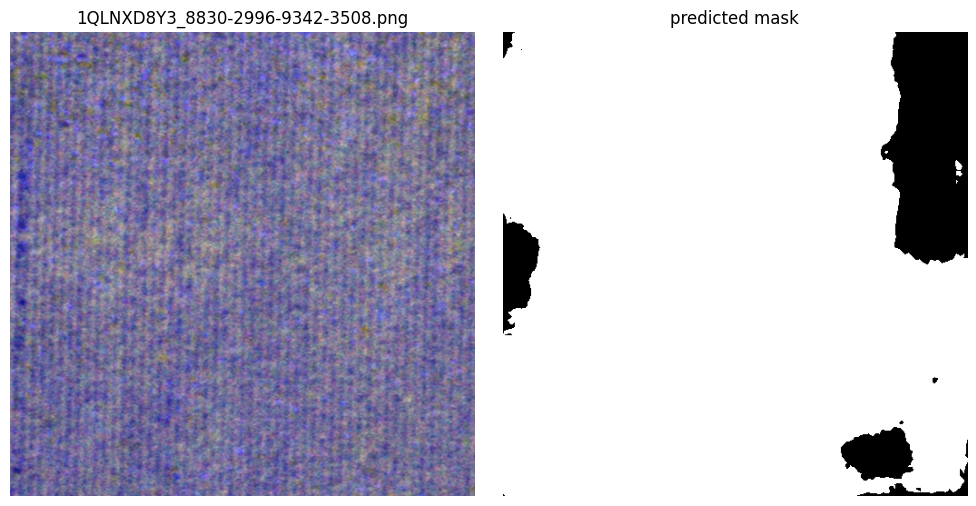

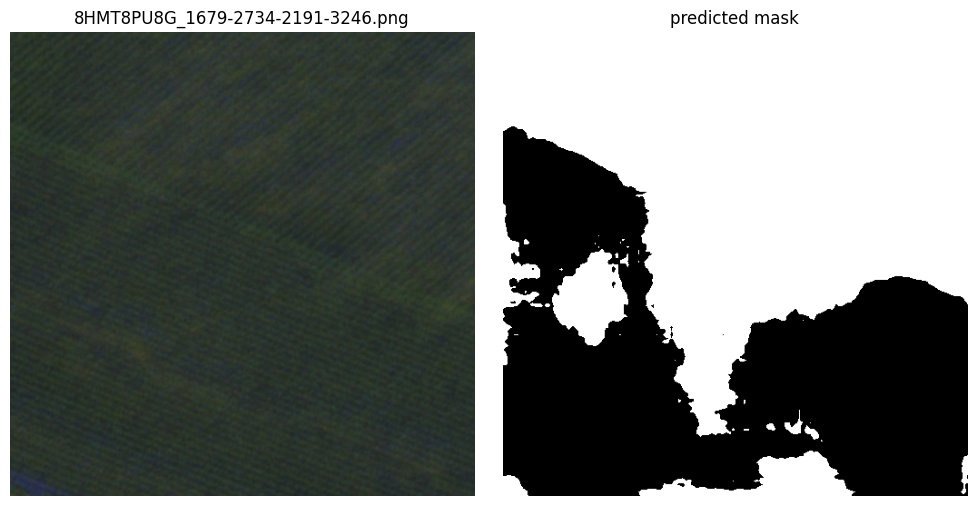

In [27]:
# Checking two more worst-false-alarm cases for a repeating pattern —
# see Methodology.md for what these show
for fname in ["1QLNXD8Y3_8830-2996-9342-3508.png", "8HMT8PU8G_1679-2734-2191-3246.png"]:
    idx = test_files.index(fname)
    rgb = Image.open(f"/content/Agriculture-Vision-2021/val/images/rgb/{fname.replace('.png', '.jpg')}")
    probs_i = all_test_probs[idx, 0].numpy()
    pred_mask = (probs_i > best_thresh).astype(np.uint8) * 255

    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    axes[0].imshow(rgb)
    axes[0].set_title(fname)
    axes[0].axis("off")
    axes[1].imshow(pred_mask, cmap="gray")
    axes[1].set_title("predicted mask")
    axes[1].axis("off")
    plt.tight_layout()
    plt.show()

# 8. Deliverable

## 8.1 Sample Results

At least five images with the predicted dry area overlay, including one wrong case, each with
predicted and true percent of area affected.

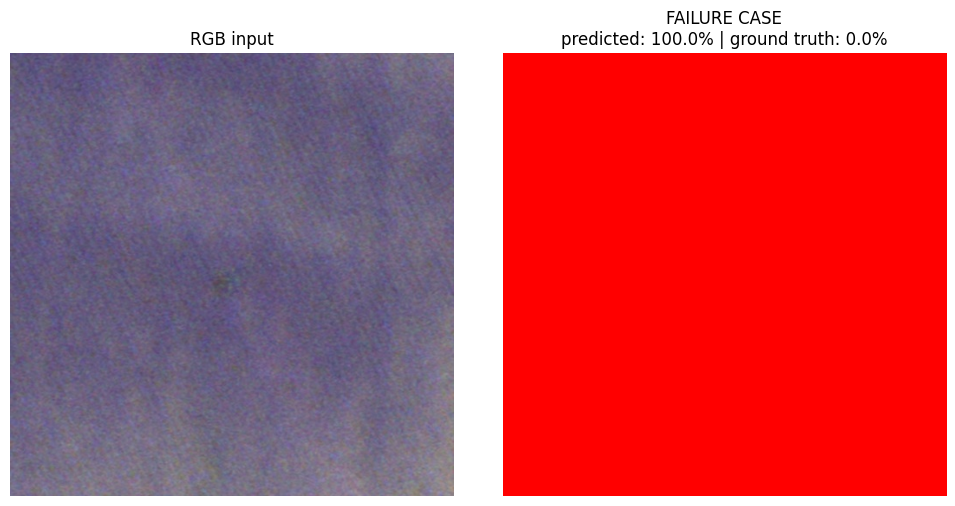

saved: /content/drive/MyDrive/Rizoma/DeepLabV3_Drydown/Enhanced/sample_results/WD9FX7QTR_4680-3357-5192-3869_result.png


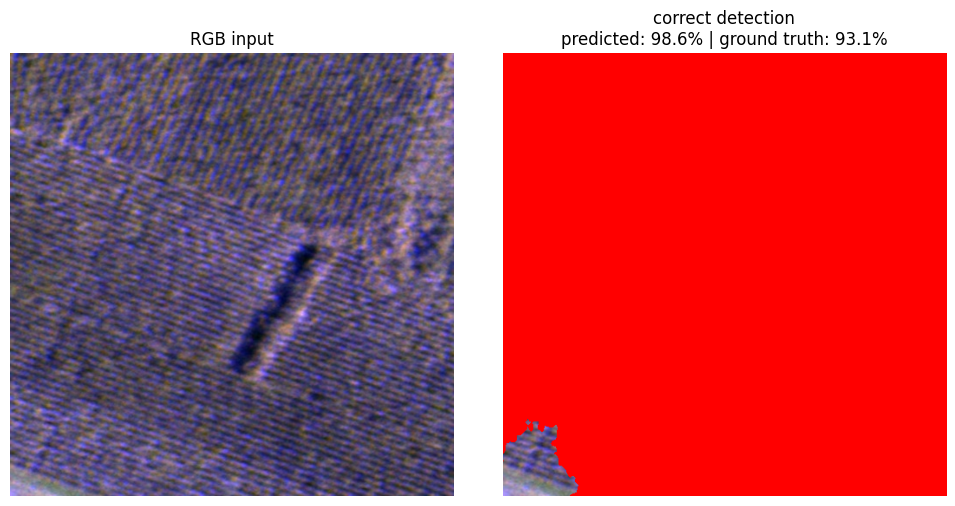

saved: /content/drive/MyDrive/Rizoma/DeepLabV3_Drydown/Enhanced/sample_results/I8AAFZ23W_9045-4141-9557-4653_result.png


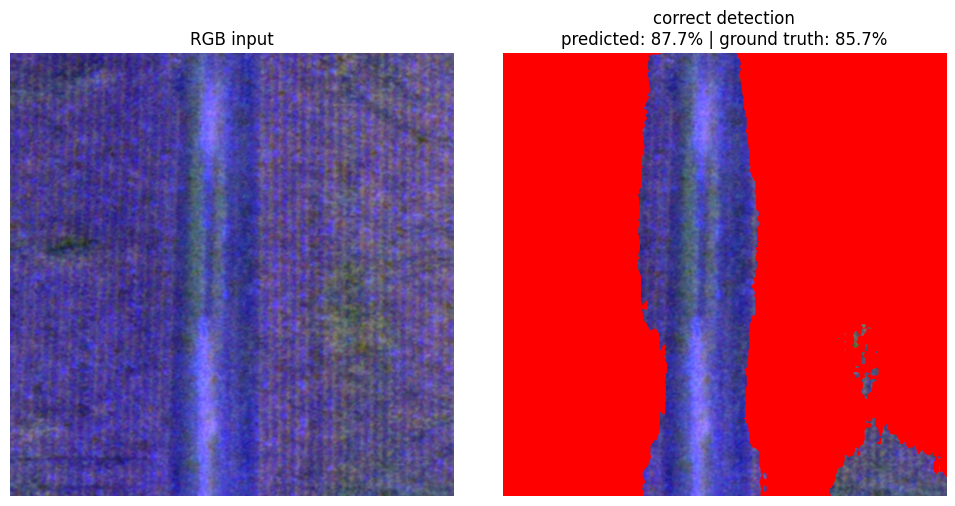

saved: /content/drive/MyDrive/Rizoma/DeepLabV3_Drydown/Enhanced/sample_results/V3YTHDHHF_6294-6162-6806-6674_result.png


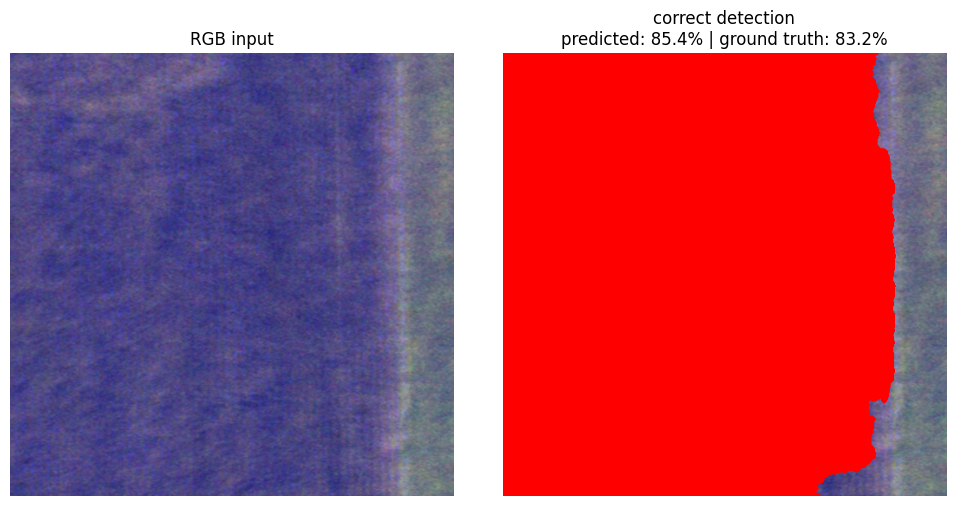

saved: /content/drive/MyDrive/Rizoma/DeepLabV3_Drydown/Enhanced/sample_results/H76EWLPT7_4701-4703-5213-5215_result.png


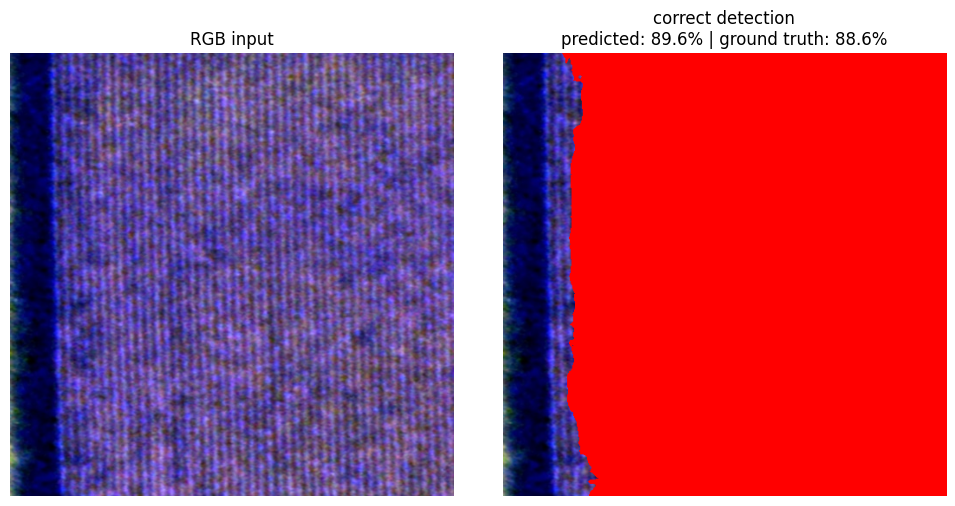

saved: /content/drive/MyDrive/Rizoma/DeepLabV3_Drydown/Enhanced/sample_results/DQXE6IG9V_776-2694-1288-3206_result.png

total sample results saved: 5


In [28]:
# % area affected = predicted/ground-truth dry pixels divided by valid field
# pixels (boundaries ∩ masks) — same formula used throughout this notebook
# and documented in Methodology.md
import os

OUT_DIR = CONFIG["sample_out_dir"]
os.makedirs(OUT_DIR, exist_ok=True)

# Required "at least 1 wrong" case + 4 strong correct examples (best genuine detections)
failure_case = "WD9FX7QTR_4680-3357-5192-3869.png"
good_cases = [f for f, _ in pos_results[-4:]]  # highest-IoU genuine detections
selected = [failure_case] + good_cases

ROOT = "/content/Agriculture-Vision-2021/val"

for fname in selected:
    idx = test_files.index(fname)
    base = fname.replace(".png", ".jpg")

    rgb = np.array(Image.open(f"{ROOT}/images/rgb/{base}").convert("RGB"))
    gt_mask = np.array(Image.open(f"{ROOT}/labels/drydown/{fname}"))
    boundary = np.array(Image.open(f"{ROOT}/boundaries/{fname}"))
    valid = np.array(Image.open(f"{ROOT}/masks/{fname}"))

    probs_i = all_test_probs[idx, 0].numpy()
    pred_mask = (probs_i > best_thresh).astype(np.uint8) * 255

    valid_area = (boundary > 0) & (valid > 0)
    pct_predicted = (pred_mask[valid_area] > 0).mean() * 100
    pct_ground_truth = (gt_mask[valid_area] > 0).mean() * 100

    overlay = rgb.copy()
    overlay[pred_mask > 0] = [255, 0, 0]

    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    axes[0].imshow(rgb)
    axes[0].set_title("RGB input")
    axes[0].axis("off")
    axes[1].imshow(overlay)
    tag = "FAILURE CASE" if fname == failure_case else "correct detection"
    axes[1].set_title(f"{tag}\npredicted: {pct_predicted:.1f}% | ground truth: {pct_ground_truth:.1f}%")
    axes[1].axis("off")
    plt.tight_layout()

    out_path = f"{OUT_DIR}/{fname.replace('.png', '')}_result.png"
    plt.savefig(out_path, dpi=100, bbox_inches="tight")
    plt.show()
    print(f"saved: {out_path}")

print(f"\ntotal sample results saved: {len(os.listdir(OUT_DIR))}")